In [107]:
#pip install ucimlrepo

In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, FunctionTransformer,
    OneHotEncoder, OrdinalEncoder,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [109]:
# Usei pra deixar os gráficos mais legiveis
LABELS = {
    'age':      'Idade',
    'sex':      'Sexo',
    'cp':       'Tipo de Dor no Peito',
    'trestbps': 'Pressão Arterial em Repouso',
    'chol':     'Colesterol Sérico',
    'fbs':      'Glicemia > 120 mg/dl',
    'restecg':  'ECG em Repouso',
    'thalach':  'Freq. Cardíaca Máxima',
    'exang':    'Angina por Exercício',
    'oldpeak':  'Depressão ST',
    'slope':    'Inclinação ST',
    'ca':       'Vasos Principais Coloridos',
    'thal':     'Talassemia',
    'target':   'Diagnóstico',
}

In [110]:
from ucimlrepo import fetch_ucirepo 
heart_disease = fetch_ucirepo(id=45) 
  
X = heart_disease.data.features 
y = heart_disease.data.targets 


In [111]:
df = X
df['target'] = y

In [112]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


| Atributo | Tipo | Descrição |
|----------|------|-----------|
| age | Contínua | Idade em anos |
| sex | Binária | Sexo (1=masc, 0=fem) |
| cp | Nominal | Tipo de dor no peito (1–4) |
| trestbps | Contínua | Pressão arterial em repouso |
| chol | Contínua | Colesterol sérico |
| fbs | Binária | Glicemia > 120 mg/dl (1=sim) |
| restecg | Ordinal | Resultado ECG em repouso (0–2) |
| thalach | Contínua | Frequência cardíaca máxima |
| exang | Binária | Angina induzida por exercício (1=sim) |
| oldpeak | Contínua | Depressão ST por exercício |
| slope | Ordinal | Inclinação do pico ST (1–3) |
| ca | Ordinal | Nº de vasos principais coloridos (0–3) |
| thal | Nominal | Resultado talassemia (3=normal, 6=fixo, 7=reversível) |
| target | Ordinal | 0 = sem doença, 1–4 = severidade da doença |

In [113]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


Observações
- chol: máximo 564 muito acima do 3 quartil - outlier.
- target: mediana 0 com média 0.94 — classe 0 é dominante

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


## Pré-processamento

In [115]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Outliers removidos por imputação de moda

In [116]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
df[['ca', 'thal']] = imputer.fit_transform(df[['ca', 'thal']])

### Outliers

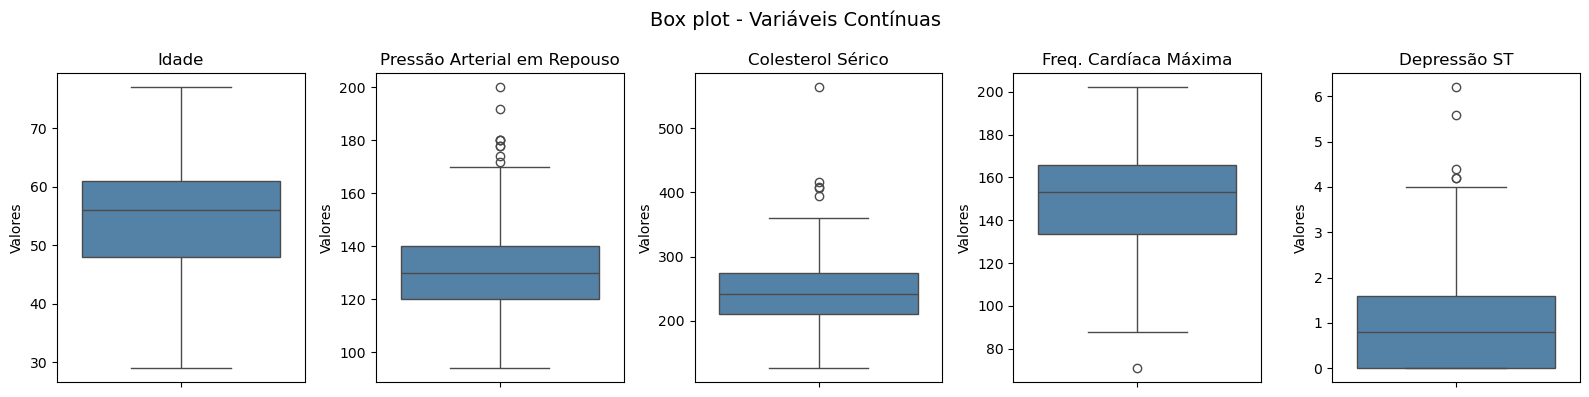

In [117]:
cont_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for i, col in enumerate(cont_features):
    sns.boxplot(data=df, y=col, ax=axes[i], color='steelblue')
    axes[i].set_title(LABELS.get(col, col))
    axes[i].set_ylabel('Valores')
fig.suptitle('Box plot - Variáveis Contínuas', fontsize=14)
plt.tight_layout()
plt.show()

A remoção dos outliers pode introduzir viés, uma vez que os dados são confiaveis, logo é melhor mante-los e mitigar impacto com normalização

## Distribuição dos dados


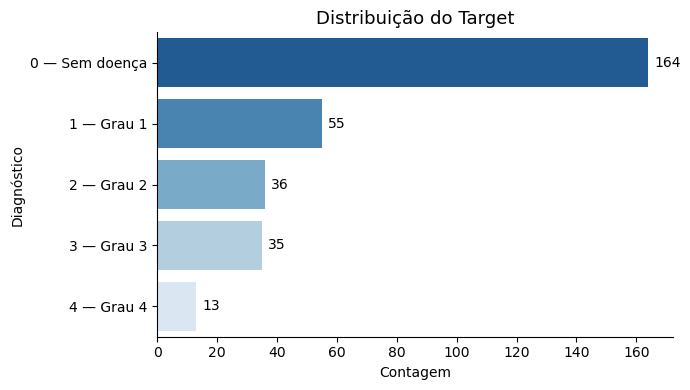

In [118]:
target_counts = df['target'].value_counts().sort_index()
labels = [f'{i} — {"Sem doença" if i == 0 else f"Grau {i}"}' for i in target_counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    x=target_counts.values,
    y=labels,
    hue=labels,
    palette='Blues_r',
    orient='h',
    legend=False,
    ax=ax,
)

for bar, val in zip(ax.patches, target_counts.values):
    ax.text(
        bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
        str(val), va='center', fontsize=10,
    )

ax.set_title('Distribuição do Target', fontsize=13)
ax.set_xlabel('Contagem')
ax.set_ylabel('Diagnóstico')
sns.despine()
plt.tight_layout()
plt.show()

Alto grau de desbalanceamento no conjunto. é melhor binarizar a variável target para apenas tentar inferir se há ou não doença, pois o knn (por haverem mais pontos da classe 0) vai acabar classificando a maioria das pessoas como saudáveis. No caso binário, ficam 139 observações para os doentes, número mais próximo de 164 dos saudáveis.

In [119]:
df['target'] = (df['target'] > 0).astype(int)
df['target'].value_counts()

target
0    164
1    139
Name: count, dtype: int64

### Variáveis Categóricas

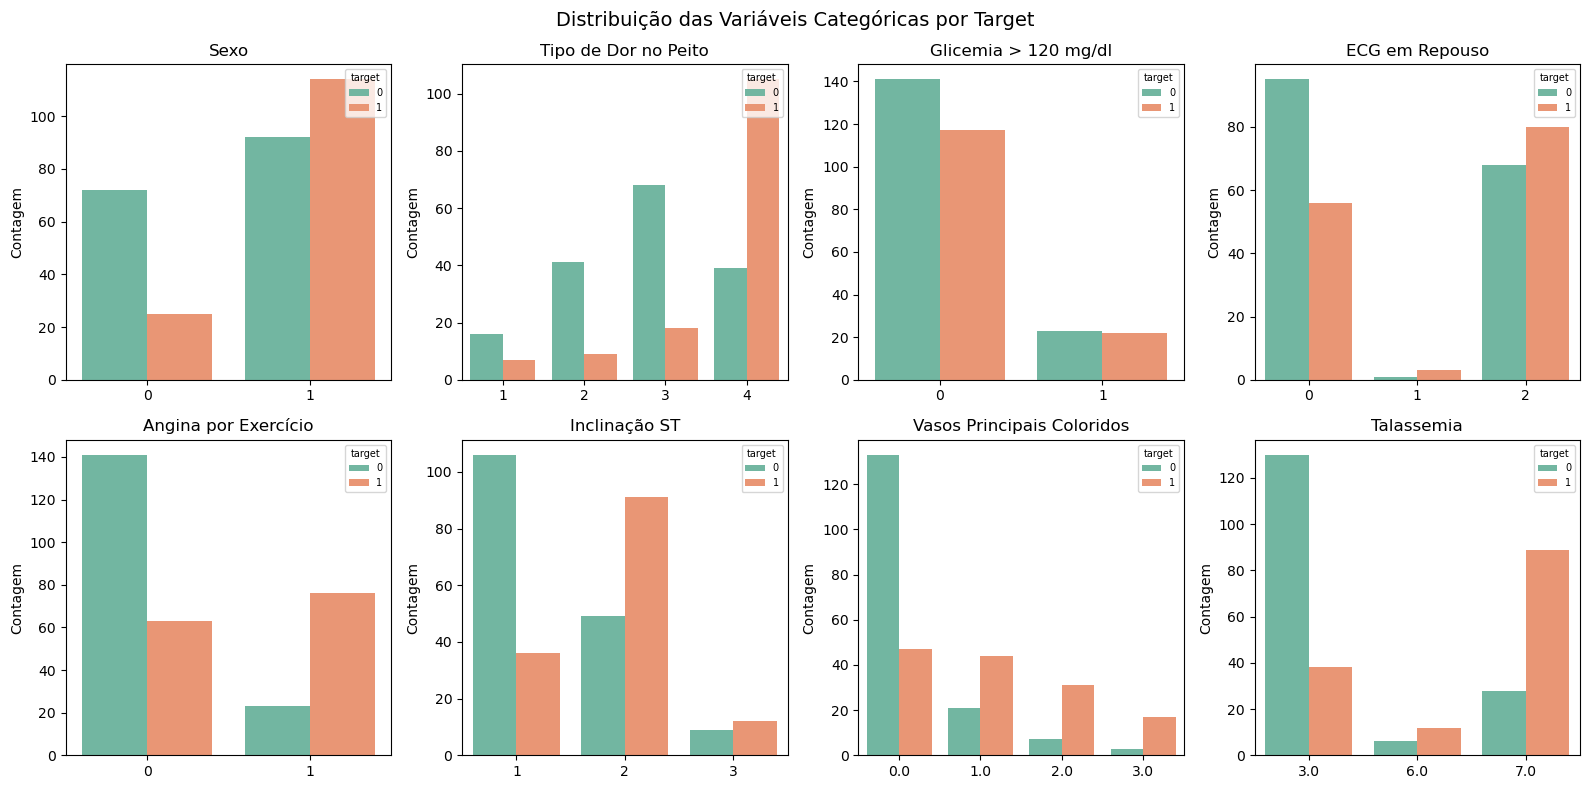

In [120]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='target', ax=axes[i], palette='Set2')
    axes[i].set_title(LABELS.get(col, col))
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Contagem')
    axes[i].legend(title='target', fontsize=7, title_fontsize=7, loc='upper right')

fig.suptitle('Distribuição das Variáveis Categóricas por Target', fontsize=14)
plt.tight_layout()
plt.show()

### Variáveis Contínuas

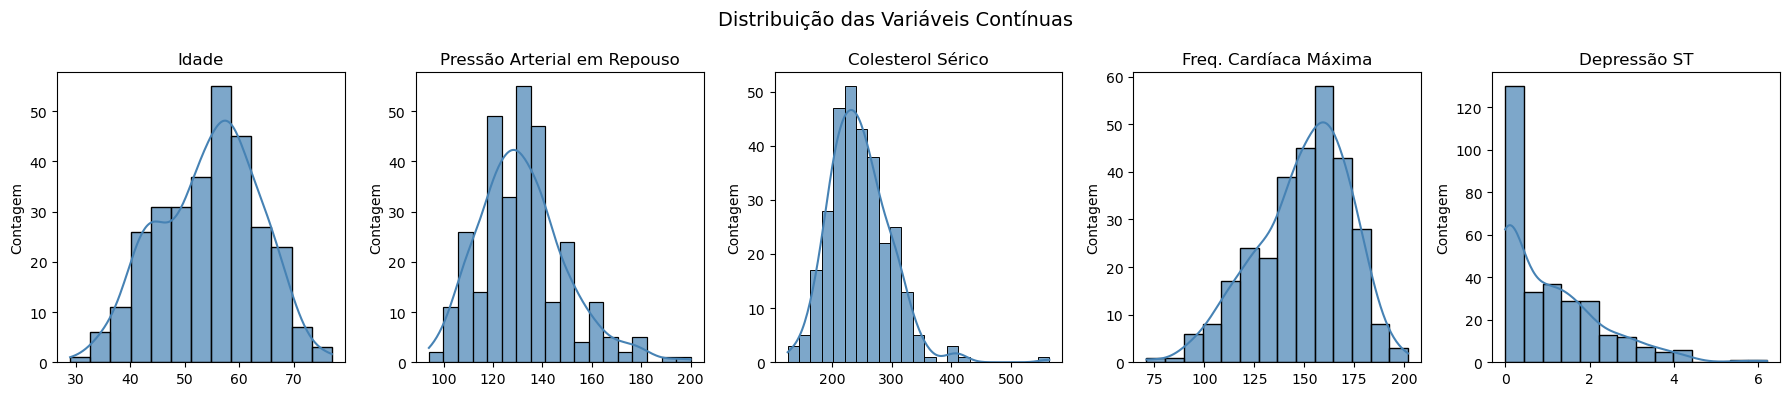

In [121]:
cont_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(cont_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='steelblue', alpha=0.7)
    axes[i].set_title(LABELS.get(col, col))
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Contagem')

fig.suptitle('Distribuição das Variáveis Contínuas', fontsize=14)
plt.tight_layout()
plt.show()

### Seleção de variáveis relevantes

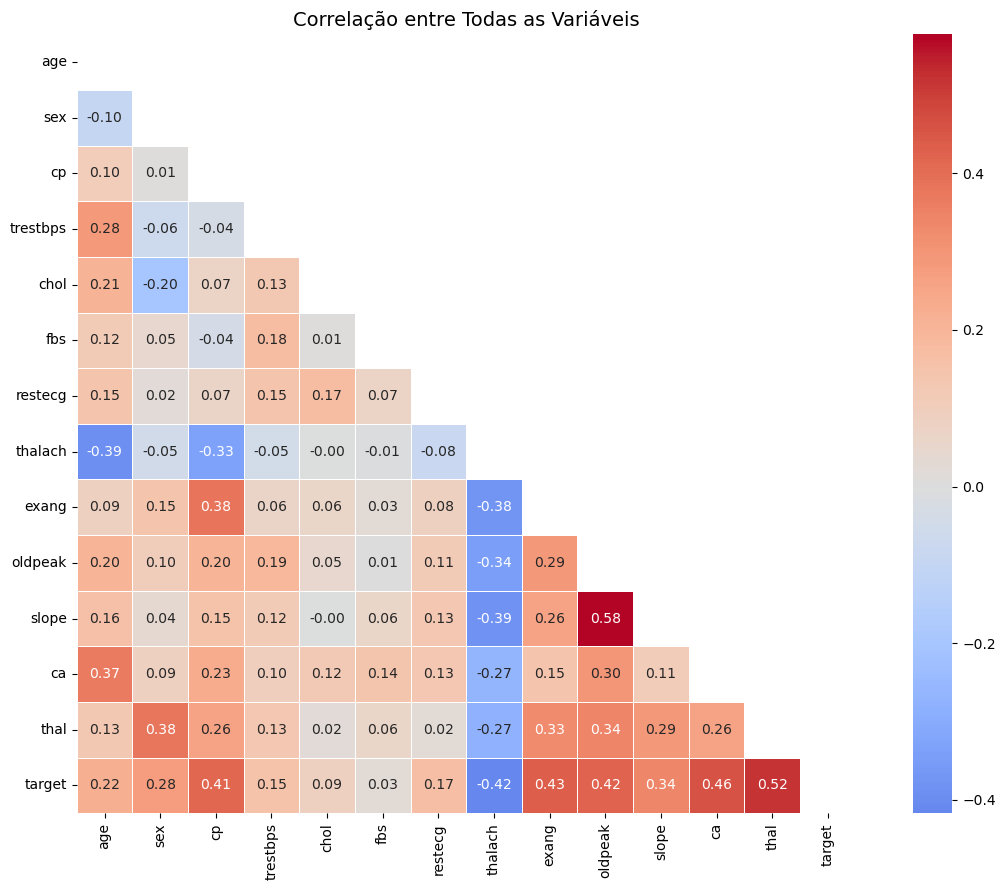

In [122]:
fig, ax = plt.subplots(figsize=(12, 9))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.5,
    square=True
)
ax.set_title('Correlação entre Todas as Variáveis', fontsize=14)
plt.tight_layout()
plt.show()

As features selecionadas foram as que apresentam maior correlação com a variável alvo no heatmap.

In [123]:
selected_features = [
    'ca',       
    'thal',     
    'oldpeak',  
    'thalach',  
    'cp',       
    'exang',    
    'slope'   
] 

X = df[selected_features]
y = df['target']

## Modelagem

Configuração de normalizações/codificações e divisão dos dados em treino e teste

In [124]:
scalers = {
    'MinMaxScaler': MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'Log': FunctionTransformer(np.log1p),
}

continuous_cols = ['oldpeak', 'thalach']
ordinal_cols = ['ca', 'slope']
passthrough_cols = ['exang']
nominal_cols = ['cp', 'thal']
numeric_all = continuous_cols + ordinal_cols
k_range = list(range(1, 30))

def build_ct(norm):
    return ColumnTransformer([
        ('numeric', norm, numeric_all),
        ('passthrough', 'passthrough', passthrough_cols),
        ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), nominal_cols),
    ])

In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Tratamento de colunas com diferentes normalizações para X

In [126]:
X_scaled = {}
for name, scaler in scalers.items():
    ct = ColumnTransformer([
        ('continuous', scaler, continuous_cols),
        ('ordinal', Pipeline([('ord', OrdinalEncoder()), ('scale', clone(scaler))]), ordinal_cols),
        ('passthrough', 'passthrough', passthrough_cols),
        ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), nominal_cols),
    ])
    X_scaled[name] = {
        'train': ct.fit_transform(X_train),
        'test':  ct.transform(X_test),
    }

## Treinamento

### Treino padrão

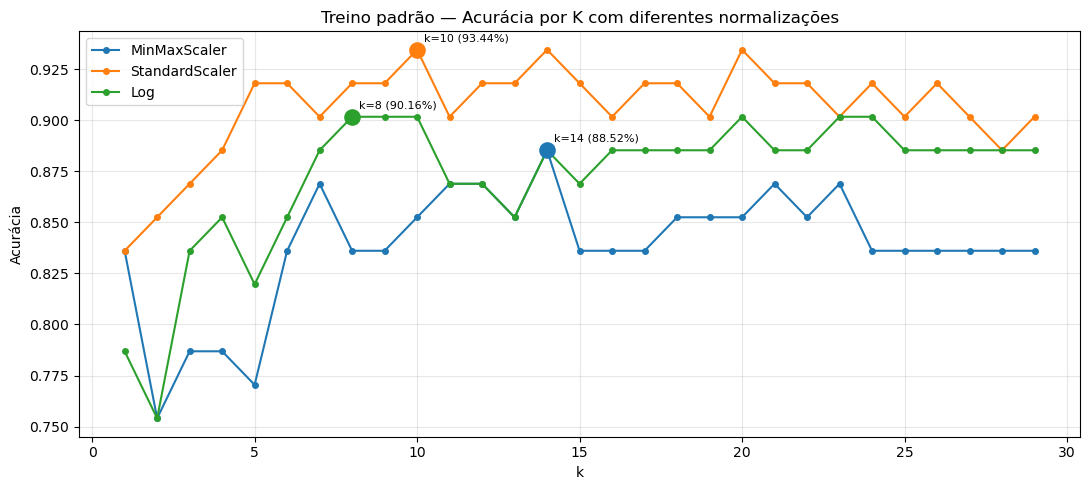

In [127]:
results = {}

for name, data in X_scaled.items():
    accs = []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(data['train'], y_train)
        accs.append(accuracy_score(y_test, knn.predict(data['test'])))
    results[name] = accs

fig, ax = plt.subplots(figsize=(11, 5))

for name, accs in results.items():
    ax.plot(k_range, accs, marker='o', markersize=4, label=name)
    best_idx = int(np.argmax(accs))
    ax.scatter(k_range[best_idx], accs[best_idx], s=120, zorder=5)
    ax.annotate(
        f"k={k_range[best_idx]} ({accs[best_idx]:.2%})",
        xy=(k_range[best_idx], accs[best_idx]),
        xytext=(5, 6), textcoords='offset points', fontsize=8
    )

ax.set_xlabel('k')
ax.set_ylabel('Acurácia')
ax.set_title('Treino padrão — Acurácia por K com diferentes normalizações')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Validação Cruzada

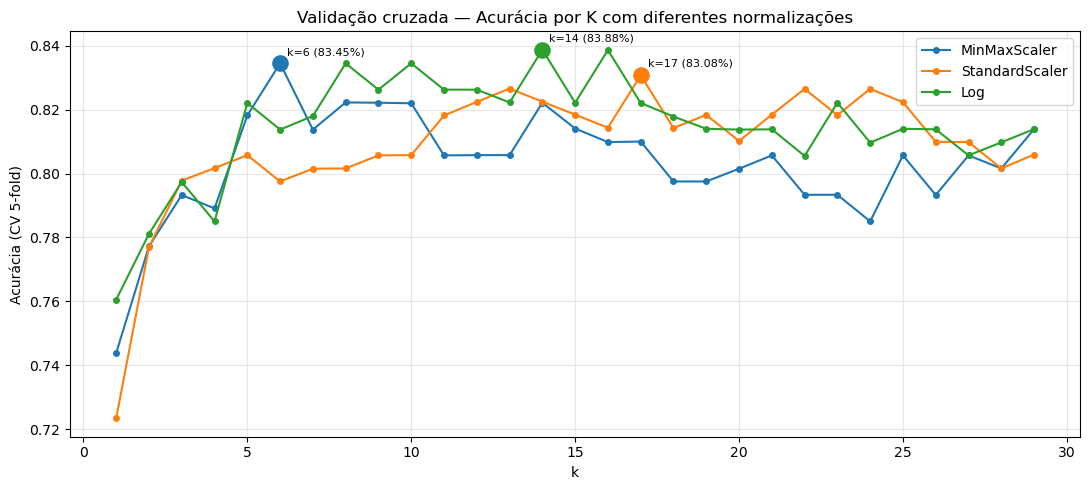

In [128]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=18)

cv_results = {}

for name, norm in scalers.items():
    accs = []
    for k in k_range:
        pipe = Pipeline([
            ('prep', build_ct(clone(norm))),
            ('knn',  KNeighborsClassifier(n_neighbors=k)),
        ])
        accs.append(cross_val_score(pipe, X_train, y_train, cv=kfold, scoring='accuracy').mean())
    cv_results[name] = accs

fig, ax = plt.subplots(figsize=(11, 5))
for name, accs in cv_results.items():
    ax.plot(k_range, accs, marker='o', markersize=4, label=name)
    best_idx = int(np.argmax(accs))
    ax.scatter(k_range[best_idx], accs[best_idx], s=120, zorder=5)
    ax.annotate(
        f"k={k_range[best_idx]} ({accs[best_idx]:.2%})",
        xy=(k_range[best_idx], accs[best_idx]),
        xytext=(5, 6), textcoords='offset points', fontsize=8
    )
ax.set_xlabel('k')
ax.set_ylabel('Acurácia (CV 5-fold)')
ax.set_title('Validação cruzada — Acurácia por K com diferentes normalizações')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Grid Search

In [129]:
param_grid = {
    'knn__n_neighbors': list(range(1, 30)),
    'knn__weights':     ['uniform', 'distance'],
    'knn__metric':      ['euclidean', 'manhattan'],
}

gs_results = {}
for name, norm in scalers.items():
    pipe = Pipeline([('prep', build_ct(clone(norm))), ('knn', KNeighborsClassifier())])
    gs = GridSearchCV(pipe, param_grid, cv=kfold, scoring='accuracy', n_jobs=-1)
    gs.fit(X_train, y_train)
    gs_results[name] = {
        'melhor_k': gs.best_params_['knn__n_neighbors'],
        'metric':   gs.best_params_['knn__metric'],
        'weights':  gs.best_params_['knn__weights'],
        'cv_acc':   round(gs.best_score_, 4),
        'test_acc': round(gs.score(X_test, y_test), 4),
    }

pd.DataFrame(gs_results).T

,melhor_k,metric,weights,cv_acc,test_acc
MinMaxScaler,9,manhattan,uniform,0.843,0.8525
StandardScaler,13,manhattan,uniform,0.8347,0.918
Log,14,euclidean,uniform,0.8388,0.8689


Melhor modelo: MinMaxScaler | k=9 | metric=manhattan | weights=uniform
Acurácia no teste: 0.8525

              precision    recall  f1-score   support

           0       0.85      0.88      0.87        33
           1       0.85      0.82      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



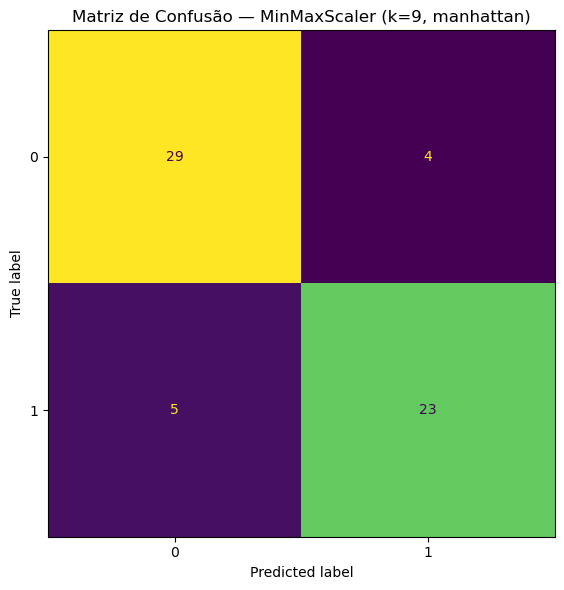

In [130]:
best_norm_name = max(gs_results, key=lambda n: gs_results[n]['cv_acc'])
best_gs = gs_results[best_norm_name]

pipe_best = Pipeline([
    ('prep', build_ct(clone(scalers[best_norm_name]))),
    ('knn',  KNeighborsClassifier(
        n_neighbors=best_gs['melhor_k'],
        metric=best_gs['metric'],
        weights=best_gs['weights'],
    )),
])
pipe_best.fit(X_train, y_train)
y_pred = pipe_best.predict(X_test)

print(f"Melhor modelo: {best_norm_name} | k={best_gs['melhor_k']} | metric={best_gs['metric']} | weights={best_gs['weights']}")
print(f"Acurácia no teste: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title(f'Matriz de Confusão — {best_norm_name} (k={best_gs["melhor_k"]}, {best_gs["metric"]})')
plt.tight_layout()
plt.show()

### Split vs CV vs Grid Search

In [131]:
split_results = {}
for name, norm in scalers.items():
    accs = []
    for k in k_range:
        ct = build_ct(clone(norm))
        X_tr = ct.fit_transform(X_train)
        X_te = ct.transform(X_test)
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_tr, y_train)
        accs.append(accuracy_score(y_test, knn.predict(X_te)))
    best_idx = int(np.argmax(accs))
    split_results[name] = {'melhor_k': k_range[best_idx], 'acc': round(accs[best_idx], 4)}

rows = []
for name in scalers:
    sp  = split_results[name]
    cv_b = {'melhor_k': k_range[int(np.argmax(cv_results[name]))], 'acc': round(max(cv_results[name]), 4)}
    gs  = gs_results[name]
    rows.append({
        'normalização': name,
        'split_k':      sp['melhor_k'],
        'split_acc':    sp['acc'],
        'cv_k':         cv_b['melhor_k'],
        'cv_acc':       cv_b['acc'],
        'gs_k':         gs['melhor_k'],
        'gs_metric':    gs['metric'],
        'gs_weights':   gs['weights'],
        'gs_cv_acc':    gs['cv_acc'],
        'gs_test_acc':  gs['test_acc'],
    })

pd.DataFrame(rows).set_index('normalização')

,split_k,split_acc,cv_k,cv_acc,gs_k,gs_metric,gs_weights,gs_cv_acc,gs_test_acc
normalização,,,,,,,,,
MinMaxScaler,14,0.8852,6,0.8345,9,manhattan,uniform,0.8430,0.8525
StandardScaler,10,0.9344,17,0.8308,13,manhattan,uniform,0.8347,0.9180
Log,8,0.9180,14,0.8388,14,euclidean,uniform,0.8388,0.8689
